#### This notebook has all the steps from for evaluation of EfficientB4 model with attention layer
#### The main purpose was to track the regions of the images that the model "paid attention"
#### The idea of attention mechanism comes from here
https://www.kaggle.com/code/kmader/attention-on-pretrained-vgg16-for-bone-age#Balance-the-distribution-in-the-training-set



In [ ]:
### This is for calculating 

import pandas as pd
df_scores = pd.read_excel(r'../../data/raw_data/ROW_DATA_Sonja_add_MV_ECMO_and_ECMO_LPS.xlsx',sheet_name='Total Score',engine='openpyxl')
df_scores_Ct_MV_LP = df_scores[0:19]


this_data = df_scores['PDF/ EXCEL correspodent Data'].values
df_scores

### Training

[Training](./Training/Attention.py)



### Evaluation

In [ ]:
VALIDATION_DIR = ['1st_part','2nd_part','3rd_part']
MODELS         = 'attention_result_EffNet/'
RESULTS        ='../../results/classification/predict_result_3cv/'

In [ ]:
#n script for loading the trained models and predict the validation set class
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Input, MaxPooling2D, Activation, BatchNormalization, Concatenate, Dropout, Add, Dense,LeakyReLU
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.applications import EfficientNetB0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.layers import Input, Flatten, Dense, Lambda
from keras.models import Model
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
import keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.python.keras.layers import InputSpec, Layer

import pandas as pd
from sklearn.metrics import classification_report
from keras.models import Model, model_from_json

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB4,EfficientNetB7
import os
##https://neptune.ai/blog/keras-metrics
from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall
from keras.layers import BatchNormalization
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten, Input, Conv2D, multiply, LocallyConnected2D, Lambda
from keras.models import Model


####True positive class ##############################################################################################
######################################################################################################################
class MulticlassTruePositives(tf.keras.metrics.Metric):
    def __init__(self, name='multiclass_true_positives', **kwargs):
        super(MulticlassTruePositives, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(tf.argmax(y_pred, axis=1), shape=(-1, 1))
        values = tf.cast(y_true, 'int32') == tf.cast(y_pred, 'int32')
        values = tf.cast(values, 'float32')
        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, 'float32')
            values = tf.multiply(values, sample_weight)
        self.true_positives.assign_add(tf.reduce_sum(values))

    def result(self):
        return self.true_positives

    def reset_state(self):
        # The state of the metric will be reset at the start of each epoch.
        self.true_positives.assign(0.)

## Model definition###################################################################################################
######################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    
    in_lay = Input((224,224,3))
    base_pretrained_model = EfficientNetB4(include_top = False, weights = 'imagenet')
    base_pretrained_model.trainable = False

    pt_depth  =base_pretrained_model.layers[-1].output_shape[-1]

    pt_features = base_pretrained_model(in_lay)
    bn_features = BatchNormalization()(pt_features)

    # here we do an attention mechanism to turn pixels in the GAP on an off

    attn_layer = Conv2D(64, kernel_size = (1,1), padding = 'same', activation = 'relu')(bn_features)
    attn_layer = Conv2D(16, kernel_size = (1,1), padding = 'same', activation = 'relu')(attn_layer)
    attn_layer = LocallyConnected2D(1, 
                                kernel_size = (1,1), 
                                padding = 'valid', 
                                activation = 'sigmoid',name='locally_connected')(attn_layer)
    # fan it out to all of the channels
    up_c2_w = np.ones((1, 1, 1, pt_depth))
    up_c2 = Conv2D(pt_depth, kernel_size = (1,1), padding = 'same', 
                   activation = 'linear', use_bias = False, weights = [up_c2_w])
    up_c2.trainable = False
    attn_layer = up_c2(attn_layer)

    mask_features = multiply([attn_layer, bn_features])
    gap_features = GlobalAveragePooling2D()(mask_features)
    gap_mask = GlobalAveragePooling2D()(attn_layer)

    # to account for missing values from the attention model
    gap = Lambda(lambda x: x[0]/x[1], name = 'RescaleGAP')([gap_features, gap_mask])
    gap_dr = Dropout(0.5)(gap)
    dr_steps = Dropout(0.25)(Dense(1024, activation = 'elu')(gap_dr))
    out_layer = Dense(3, activation = 'linear')(dr_steps) # linear is what 16bit did

    Lung_score_model = Model(inputs = [in_lay], outputs = [out_layer])

    METRICS = [
          keras.metrics.SparseCategoricalAccuracy(),
          ]
    Lung_score_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',  metrics = [METRICS])

    return  Lung_score_model


######################################################################################################################
###Here we add a column to our dataframe to compare different models
first_exp_col =np.zeros(len(df_scores['(sanned slide) Sample Name ']))
model_name       = 'EffNet_attn'  ## We named the model here


tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in VALIDATION_DIR:
    val_dir          = val_s # loop over all groups as validation dataset
    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = '../../data/folded_data/3fold_CV/All_samples_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set
    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   
    ###############################################################################################################
    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob(MODELS+val_dir+'*.hdf5')
    print(weights)
    # Load weights, select between best_weights (val_accuracy) and final_weights from last epoch
    pretrained_model.load_weights(weights[0])

    # Make predictions on validation samples
    with tf.device('/CPU:0'):   ## by commenting this line the prediction would run on GPU 
        preds = pretrained_model.predict(validation_samples)
    
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))

    ###################################################################################################################
    ### Here all predicted labels are saved in the following file
    with open(validation_LABEL_PATH,'r') as f: 
        with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','w') as fout: 
            for i,line in zip(y_pred,f):
                print(line.split(' ')[0 ],int(i),sep=' ',file=fout)
        fout.close()
    f.close()


    #################################################Slide score #####################################################
    ##################################################################################################################
    ### This is for extracting slide number from images to add
    keys = []
    Slide_dict = {}
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][6:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    ### Add all scores of tiles to the slide key
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][6:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))
    #### Change all tile scores to the score of majority of tiles for slide score 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        offset += len(Slide_dict[k])
    ##################################################################################################################
    
    ##############################################Image score ########################################################
    ##################################################################################################################
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    
    #### Change all tile scores to the score of majority of tiles for each image 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        offset += len(Image_dict[k])

    
    ##################################################################################################################
    
    

## Visualization

In [4]:
Result_path = '../../results/classification/predict_result_3cv/'
validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'EffNet_attn'


[[2806  331  231]
 [ 562 1434  672]
 [   0  210 1827]]


<Figure size 640x480 with 0 Axes>

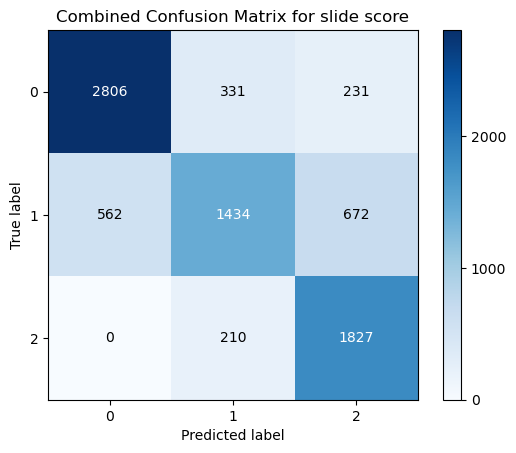

<Figure size 640x480 with 0 Axes>

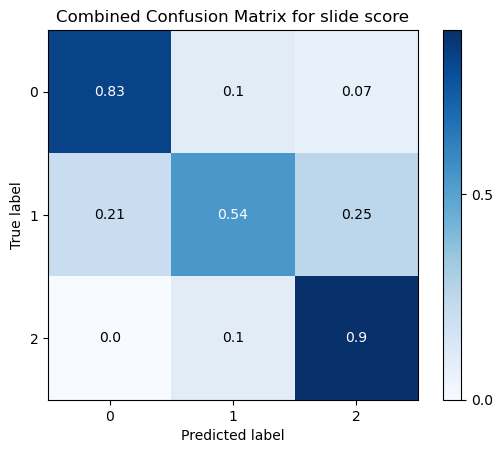

<Figure size 640x480 with 0 Axes>

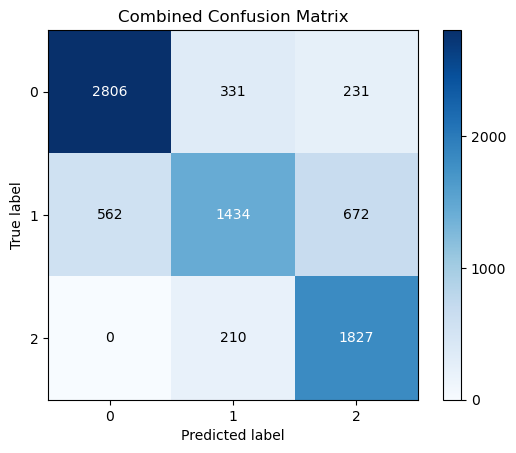

<Figure size 640x480 with 0 Axes>

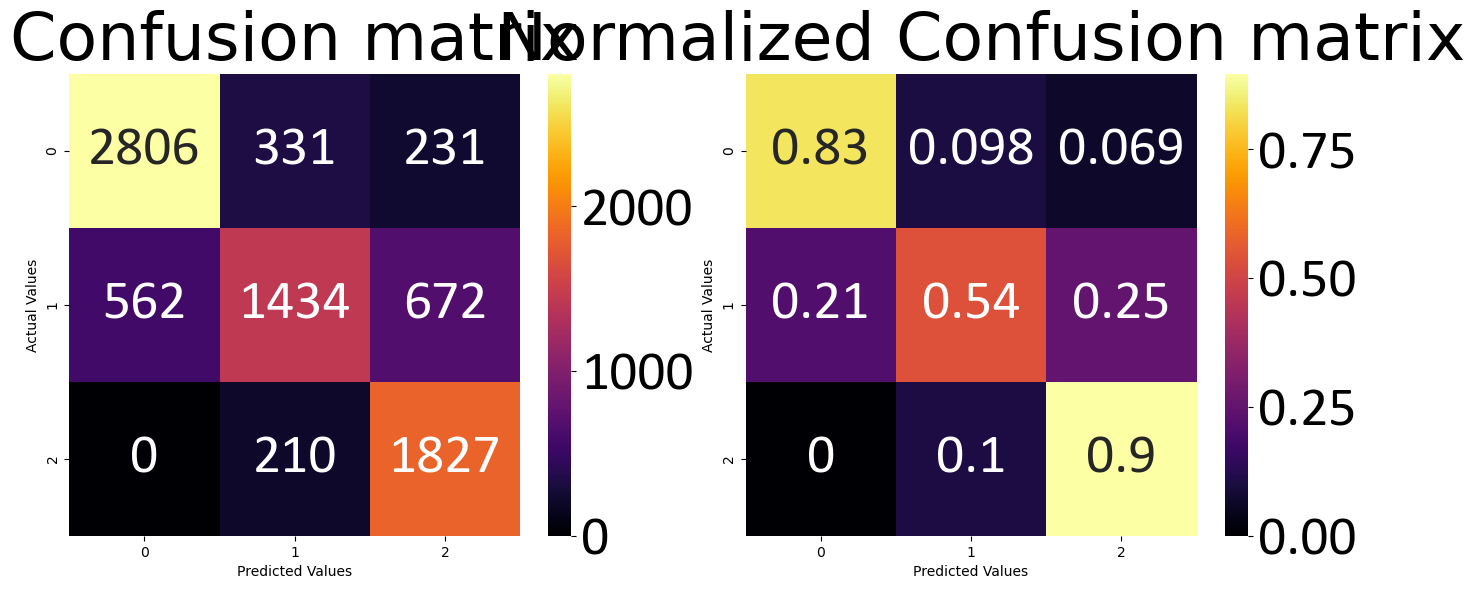

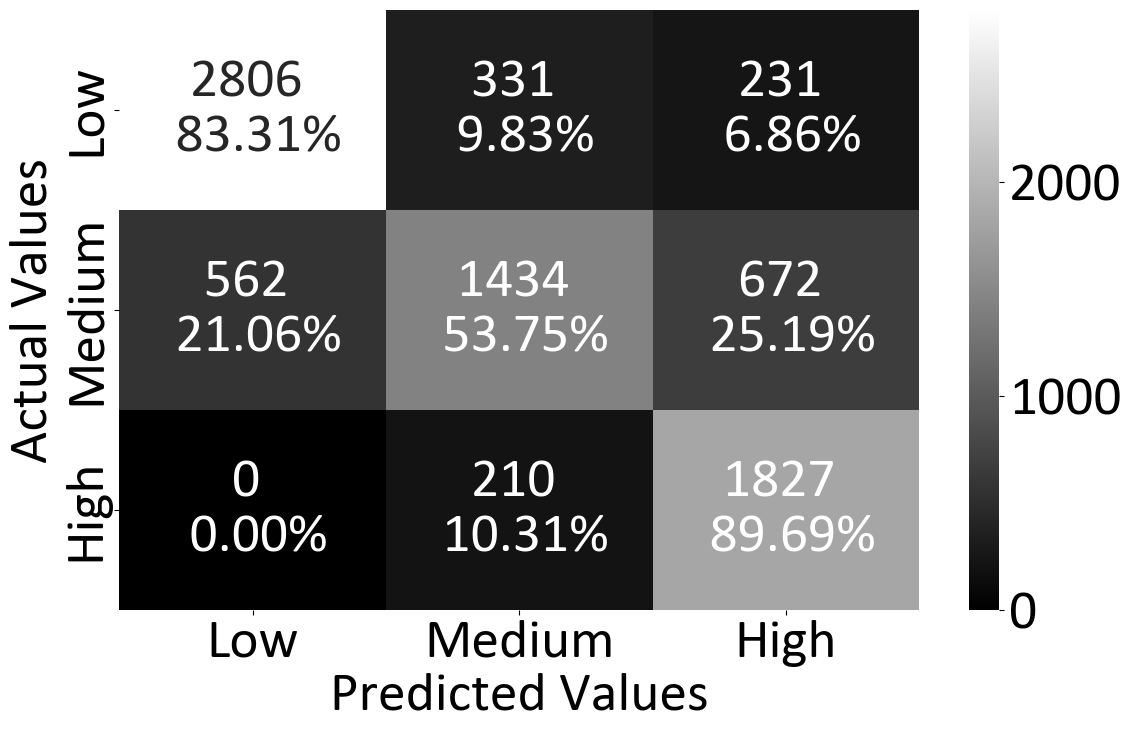

In [ ]:
import glob
import matplotlib.pyplot as plt
import numpy as np


from sklearn.metrics import precision_score, recall_score, f1_score,multilabel_confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall

G_s = []
P_s = []

max_score = max(df_scores['Median'])
min_score = min(df_scores['Median'])

##Normalized thresholds
tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
##Normalized thresholds
low = (10-(min_score))/(max_score-min_score)
mid = (25-(min_score))/(max_score-min_score)

#################Loop over all folds################################################################################

for val_dir in validation_slide:
    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = '../../data/folded_data/3fold_CV/All_samples_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

  
    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_label = np.zeros((n_v,), int)
    
    ######################################################################################################
    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            #validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
    
############################################################################################################    
    y_pred = []  
    with open(Result_path+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as f:
        for line in f:
            y_pred.append(int(line.split(' ')[1].strip()))  

   ##############################################################################################    
    keys = []
    Slide_dict = {}
    flag_28  = False
    with open(Result_path + model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][0:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open(Result_path + model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][0:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))
    #print(Slide_dict.keys())
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open(Result_path+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open(Result_path+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        offset += len(Image_dict[k])

    

    
    #############################################Tile scores ###########################################################

    tile_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                               columns=['Precision','Recall','F1-score'])
   #####################################################################################################################
   ### Precision column ################################################################################################ 
    prec_col = np.zeros((1,5))
    tile_classes = precision_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division=0)
    tile_Micro = precision_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division=0)
    tile_weighted = precision_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division=0)
    
    prec_col[0,0:3] = tile_classes
    prec_col[0,3] = tile_Micro
    prec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Precision']  = prec_col.transpose()
    ###################################################################################################################
    ### Recall column #############################################################################################
    rec_col = np.zeros((1,5))
    tile_classes = recall_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division=0)
    tile_Micro = recall_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division=0)
    #tile_Macro = recall_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = recall_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division=0)
    
    rec_col[0,0:3] = tile_classes
    rec_col[0,3] = tile_Micro
    rec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Recall']  = rec_col.transpose()
    ###################################################################################################################
    ####F1-score column################################################################################################
    f1_score_col = np.zeros((1,5))
    tile_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None,zero_division=0)
    tile_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro',zero_division=0)
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted',zero_division=0)
    
    f1_score_col[0,0:3] = tile_classes
    f1_score_col[0,3] = tile_Micro
    f1_score_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
   

    ################################################################################################################# 
    ################################################Image scores ####################################################   
    image_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','Macro_average','weighted_average'],columns=['Precision','Recall','F1-score','support'])
    ########Precision column #####################
    prec_col = np.zeros((1,6))
    image_classes = precision_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division=0)
    image_Micro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division=0)
    image_Macro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division=0)
    image_weighted = precision_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division=0)
    
    prec_col[0,0:3] = image_classes
    prec_col[0,3] = image_Micro
    prec_col[0,4] = image_Macro
    prec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #################################################################################################################
    ########Recall column ###########################################################################################
    rec_col = np.zeros((1,6))
    image_classes = recall_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division=0)
    image_Micro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division=0)
    image_Macro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division=0)
    image_weighted = recall_score(precise_scores,y_pred_image, sample_weight=None,average='weighted')
    
    rec_col[0,0:3] = image_classes
    rec_col[0,3] = image_Micro
    rec_col[0,4] = image_Macro
    rec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Recall']  = rec_col.transpose()
    ####################################################################################################################
    ##########F1-score column ###########################################################################################
    f1_score_col = np.zeros((1,6))
    image_classes = f1_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None,zero_division=0)
    image_Micro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='micro',zero_division=0)
    image_Macro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='macro',zero_division=0)
    image_weighted =  f1_score(precise_scores,y_pred_image, sample_weight=None,average='weighted',zero_division=0)
    
    f1_score_col[0,0:3] = image_classes
    f1_score_col[0,3] = image_Micro
    f1_score_col[0,4] = image_Macro
    f1_score_col[0,5] = image_weighted
    
    if (prec_col+rec_col).all():
        f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    else :
        f1_score_col = np.ones((1,6))*0.1
    image_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #####################################################################################################################
    
    
    ##################################################Support (Number of data points)####################################   
    supprt_col = np.zeros((1,6))
    image_class0 = np.sum(np.array(precise_scores) == 0)
    image_class1 = np.sum(np.array(precise_scores) == 1)
    image_class2 = np.sum(np.array(precise_scores) == 2)
    
    image_Micro    = len(precise_scores)
    image_Macro    = len(precise_scores)
    image_weighted = len(precise_scores)
    
    supprt_col[0,0] = image_class0
    supprt_col[0,1] = image_class1
    supprt_col[0,2] = image_class2
    
    supprt_col[0,3] = image_Micro
    supprt_col[0,4] = image_Macro
    supprt_col[0,5] = image_weighted
    image_based_scores[val_dir]['support']  =  supprt_col.transpose()
    
    
    ######################################################Slide scores ###################################################
    slide_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                                columns=['Precision','Recall','F1-score'])
   ########################################################################################################################
   ##Precise column ############################################
    
    prec_col = np.zeros((1,5))
    slide_classes = precision_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None,zero_division=0 )
    slide_Micro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='micro',zero_division=0)
    #slide_Macro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='weighted',zero_division=0)
    
    prec_col[0,0:3] = slide_classes
    prec_col[0,3] = slide_Micro
    #prec_col[0,4] = slide_Macro
    prec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #######################################################################################################################
    ########recall column #######################################
    rec_col = np.zeros((1,5))
    slide_classes = recall_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None,zero_division=0)
    slide_Micro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='micro',zero_division=0)
    #slide_Macro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = recall_score(precise_scores,y_pred_slide,average='weighted',zero_division=0)
    
    rec_col[0,0:3] = slide_classes
    rec_col[0,3] = slide_Micro
    #rec_col[0,4] = slide_Macro
    rec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #######################################################################################################################
    ###F1-score column ########################################
    ## Is calculated from averaged Precision and Recall. 
    f1_score_col = np.zeros((1,5))
    if (prec_col+rec_col).all():
        f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    else :
        f1_score_col = np.ones((1,5))*0.1
    slide_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #########################################################################################
    
    G_s = np.append(G_s, precise_scores)
    P_s = np.append(P_s, y_pred_slide)
    #############################
    #############################
 #################################################################################################################    
 ################################################################################################
df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_img  = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,
                       keys=['fold1','fold2','fold3'])

###################################################################################################
## Merge tile based scores##########################################################################
df_1_tile = np.array(df_tile.iloc[0:6,0:3]).astype(float)
df_2_tile = np.array(df_tile.iloc[0:6,3:6]).astype(float)
df_3_tile = np.array(df_tile.iloc[0:6,6:9]).astype(float)

a = [df_1_tile,df_2_tile,df_3_tile]

tile_mean = np.mean(a,axis=0)

tile_m = pd.DataFrame(tile_mean,columns= ['Precision','Recall','F1-score'],index = ['Low','Medium','High','Micro_average','weighted_average'])
tile_m

tile_m['F1-score'] = (2*tile_m['Precision']*tile_m['Recall'])/(tile_m['Precision']+tile_m['Recall'])
tile_m
####################################################################################################
###Merge Image based scores (weighted) #########################################################################

df_1_img = np.array(df_img.iloc[0:7,0:3]).astype(float)
df_2_img = np.array(df_img.iloc[0:7,4:7]).astype(float)
df_3_img = np.array(df_img.iloc[0:7,8:11]).astype(float)

weights_1 = np.array(df_img.iloc[0:7,3]).astype(float)*np.identity(6)
weights_2 = np.array(df_img.iloc[0:7,7]).astype(float)*np.identity(6)
weights_3 = np.array(df_img.iloc[0:7,11]).astype(float)*np.identity(6)

sum_weights = np.matmul((weights_1+weights_2+weights_3),np.ones([6,1]))
b = [np.matmul(weights_1/sum_weights,df_1_img),np.matmul(weights_2/sum_weights,df_2_img),
    np.matmul(weights_3/sum_weights,df_3_img)]

img_mean = np.sum(b,axis=0)
img_m = pd.DataFrame(img_mean,columns= ['precision','recall','f1-score'],index = ['Low','Medium','High','Micro_average','Macro_average','weighted_average'])
img_m

###################################################################################################
###Merge Slide based scores (weighted) ############################################################
df_1_slide = np.array(df_slide.iloc[0:6,0:3]).astype(float)
df_2_slide = np.array(df_slide.iloc[0:6,3:6]).astype(float)
df_3_slide = np.array(df_slide.iloc[0:6,6:9]).astype(float)


a = [df_1_slide,df_2_slide,df_3_slide]

slide_mean = np.mean(a,axis=0)
slide_m = pd.DataFrame(slide_mean,columns= ['Precision','Recall','F1-score'],
                       index = ['Low','Medium','High','Micro_average','weighted_average'])

slide_m['F1-score'] = (2*slide_m['Precision']*slide_m['Recall'])/(slide_m['Precision']+slide_m['Recall'])

#######################################################################################################
########### Plotting  Combined scores for tile and slide ########################################################

import seaborn as sns
plt.figure()
plot_confusion_matrix(G_s, P_s,labels=my_bins)
plt.title('Combined Confusion Matrix for slide score')
    
plt.figure()
plot_confusion_matrix(G_s, P_s,labels=my_bins,normalize='true')
plt.title('Combined Confusion Matrix for slide score')

plt.figure()
plot_confusion_matrix(G_s,P_s,labels=my_bins)
plt.title('Combined Confusion Matrix')

plt.figure()
print(confusion_matrix(G_s,P_s))


cm_normalized = confusion_matrix(G_s,P_s).astype('float') / confusion_matrix(G_s,P_s).sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
rc = {'figure.figsize':(10,6),
      'axes.facecolor':'white',
      'axes.grid' : False,
      'grid.color': '.6',
      'font.family':'Calibri',
      'font.size' :40}
plt.rcParams.update(rc)

sns.heatmap(confusion_matrix(G_s,P_s),fmt="", annot=True, ax = ax1,cmap='inferno')
ax1.set_title('Confusion matrix')
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Actual Values')

sns.heatmap(cm_normalized, annot=True, ax = ax2,cmap='inferno')
ax2.set_title(' Normalized Confusion matrix')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Actual Values')
plt.show()

########################################################################################
GPS= confusion_matrix(G_s,P_s)
NGPS = cm_normalized

labels = (np.asarray(["{0} \n {1:0.2f}%".format(t, 100*s)
                      for t, s in zip(GPS.flatten(),
                                               NGPS.flatten())])
         ).reshape(3, 3)

fig_2 = plt.figure(figsize = (10,6))

ax = fig_2.add_axes([1,0,1,1])
sns.heatmap(GPS, annot=labels, fmt="", ax=ax,yticklabels=['Low','Medium','High'],xticklabels=['Low','Medium','High'],cmap='gray')
#ax.set_title(' Normalized Confusion matrix')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
plt.show()

rc = {'figure.figsize':(10,6),
      'axes.facecolor':'gray',
      'axes.grid' : False,
      'font.family':'Nato',
      'font.size' :40}
plt.show()



##########################################################################################################
#### Combined dataframes for all folds
df_effnet_man_aug_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part'],tile_m], axis=1,keys=['fold1','fold2','fold3','Average'])
#df_effnet_man_aug_tile

df_effnet_man_aug_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part'],slide_m], axis=1,keys=['fold1','fold2','fold3','Average'])
#df_effnet_man_aug_slide



